In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Datasets

In [2]:
# Testing Dataframe
df1 = pd.read_parquet('C:\Code\ML_Project\Data\merged_testing.parquet')
# Training Dataframe
df2 = pd.read_parquet('C:\Code\ML_Project\Data\merged_training.parquet')

### Testing Dataframe Clean

In [3]:
df1.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,48,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
1,17,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
2,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
4,17,1,2,0,2896.0,0.0,1448.0,1448.0,1448.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS


In [4]:
df1.describe()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,306201.000000,3.062010e+05,306201.000000,306201.000000,3.062010e+05,3.062010e+05,306201.000000,306201.000000,306201.000000,306201.000000,...,306201.000000,3.062010e+05,3.062010e+05,3.062010e+05,3.062010e+05,3.062010e+05,306201.0,3.062010e+05,3.062010e+05,3.062010e+05
mean,15.604273,3.585094e+06,30.088723,1.201462,1.294086e+04,9.254952e+02,424.750305,365.666931,401.790314,18.453783,...,28.472683,-2.760542e+07,1.506202e+04,4.490446e+03,2.078849e+04,1.220319e+04,923250.5,8.577780e+04,9.988114e+05,8.534713e+05
std,3.703168,1.360677e+07,52.760743,18.144399,4.032489e+04,5.101404e+04,272.563171,250.891647,235.405502,60.612854,...,52.298030,1.690692e+08,2.407840e+05,8.287039e+04,2.924752e+05,2.284208e+05,5783805.0,9.849378e+05,6.128712e+06,5.579687e+06
min,0.000000,1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.408238e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
25%,17.000000,8.070000e+02,4.000000,0.000000,1.886000e+03,0.000000e+00,440.000000,152.000000,380.000000,0.000000,...,3.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
50%,17.000000,2.078800e+04,6.000000,0.000000,2.088000e+03,0.000000e+00,440.000000,440.000000,440.000000,0.000000,...,3.000000,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
75%,17.000000,3.000190e+06,31.000000,0.000000,1.232000e+04,0.000000e+00,516.000000,516.000000,516.000000,0.000000,...,28.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
max,17.000000,1.199987e+08,5063.000000,4602.000000,1.526642e+07,1.099376e+07,32120.000000,2021.000000,3015.290527,2221.556152,...,5043.000000,1.480000e+03,1.310114e+07,1.100562e+07,1.941638e+07,1.310114e+07,119219448.0,6.600292e+07,1.192194e+08,1.192194e+08


In [5]:
len(df1.columns)

78

In [6]:
df1.shape

(306201, 78)

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306201 entries, 0 to 306200
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  306201 non-null  int8   
 1   Flow Duration             306201 non-null  int32  
 2   Total Fwd Packets         306201 non-null  int16  
 3   Total Backward Packets    306201 non-null  int16  
 4   Fwd Packets Length Total  306201 non-null  float32
 5   Bwd Packets Length Total  306201 non-null  float32
 6   Fwd Packet Length Max     306201 non-null  float32
 7   Fwd Packet Length Min     306201 non-null  float32
 8   Fwd Packet Length Mean    306201 non-null  float32
 9   Fwd Packet Length Std     306201 non-null  float32
 10  Bwd Packet Length Max     306201 non-null  float32
 11  Bwd Packet Length Min     306201 non-null  float32
 12  Bwd Packet Length Mean    306201 non-null  float32
 13  Bwd Packet Length Std     306201 non-null  f

In [8]:
df1.isnull().sum()

Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Label                       0
Length: 78, dtype: int64

In [9]:
df1.isnull().sum().sum()

np.int64(0)

In [10]:
df1.dropna(inplace=True)

### Training Dataframe Clean

In [11]:
df2.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,49,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
1,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
2,17,1,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
4,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP


In [12]:
df2.describe()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,125170.000000,1.251700e+05,125170.000000,125170.000000,125170.000000,1.251700e+05,125170.000000,125170.000000,125170.000000,125170.000000,...,125170.000000,1.251700e+05,1.251700e+05,1.251700e+05,1.251700e+05,1.251700e+05,125170.0,1.251700e+05,1.251700e+05,1.251700e+05
mean,9.898682,2.019535e+07,9.584709,5.580163,796.494202,3.363396e+03,192.930588,121.169594,136.857559,24.500202,...,5.797675,-1.226480e+07,7.932495e+04,7.736733e+04,1.820170e+05,3.453661e+04,6184596.0,1.507536e+06,7.796018e+06,4.783568e+06
std,5.325327,3.016285e+07,353.744074,100.657786,2842.494629,1.806905e+05,364.794006,246.966614,251.412918,91.285248,...,56.595554,1.135435e+08,4.617997e+05,3.876600e+05,8.356725e+05,3.852418e+05,10694075.0,3.169932e+06,1.254144e+07,9.685055e+06
min,0.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.408238e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.000000,3.510000e+02,2.000000,0.000000,36.000000,0.000000e+00,6.000000,6.000000,6.000000,0.000000,...,1.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.000000,1.089590e+05,4.000000,2.000000,72.000000,1.200000e+01,6.000000,6.000000,6.000000,0.000000,...,3.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
75%,17.000000,4.421370e+07,10.000000,4.000000,1038.000000,3.600000e+01,377.000000,50.000000,211.000000,5.196152,...,7.000000,2.000000e+01,3.633333e+01,3.111270e+01,1.000000e+02,1.000000e+00,12028475.0,2.178787e+06,1.551314e+07,7.616291e+06
max,17.000000,1.199975e+08,86666.000000,31700.000000,208524.000000,5.842950e+07,3625.000000,2131.000000,2131.000000,1448.583008,...,18766.000000,6.724045e+07,4.050800e+07,2.135244e+07,4.553668e+07,4.050800e+07,117569200.0,6.961402e+07,1.175692e+08,1.175692e+08


In [13]:
len(df2.columns)

78

In [14]:
df2.shape

(125170, 78)

In [15]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125170 entries, 0 to 125169
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  125170 non-null  int8   
 1   Flow Duration             125170 non-null  int32  
 2   Total Fwd Packets         125170 non-null  int32  
 3   Total Backward Packets    125170 non-null  int16  
 4   Fwd Packets Length Total  125170 non-null  float32
 5   Bwd Packets Length Total  125170 non-null  float32
 6   Fwd Packet Length Max     125170 non-null  float32
 7   Fwd Packet Length Min     125170 non-null  float32
 8   Fwd Packet Length Mean    125170 non-null  float32
 9   Fwd Packet Length Std     125170 non-null  float32
 10  Bwd Packet Length Max     125170 non-null  float32
 11  Bwd Packet Length Min     125170 non-null  float32
 12  Bwd Packet Length Mean    125170 non-null  float32
 13  Bwd Packet Length Std     125170 non-null  f

In [16]:
df2.isnull().sum()

Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Label                       0
Length: 78, dtype: int64

In [17]:
df2.isnull().sum().sum()

np.int64(0)

In [18]:
df2.dropna(inplace=True)

In [19]:
df2["Label"].value_counts()

Label
Syn        48840
Benign     46427
UDP        18090
MSSQL       8523
LDAP        1906
Portmap      685
NetBIOS      644
UDPLag        55
Name: count, dtype: int64

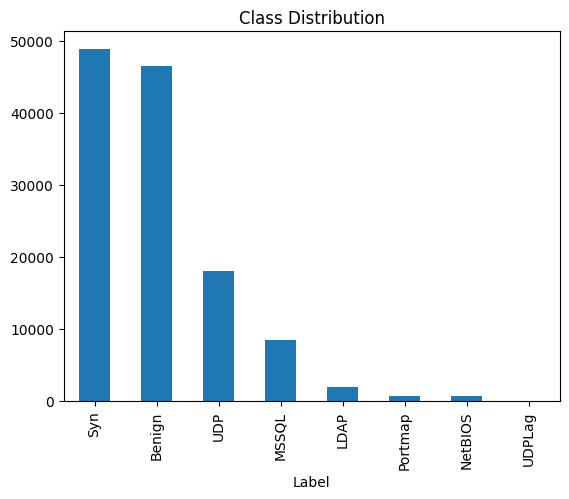

In [20]:
df2["Label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

In [21]:
df2.replace([np.inf, -np.inf], np.nan, inplace=True)
df2.fillna(0, inplace=True)

#### Check Correlation of features for both Datasets

##### Testing Correlation

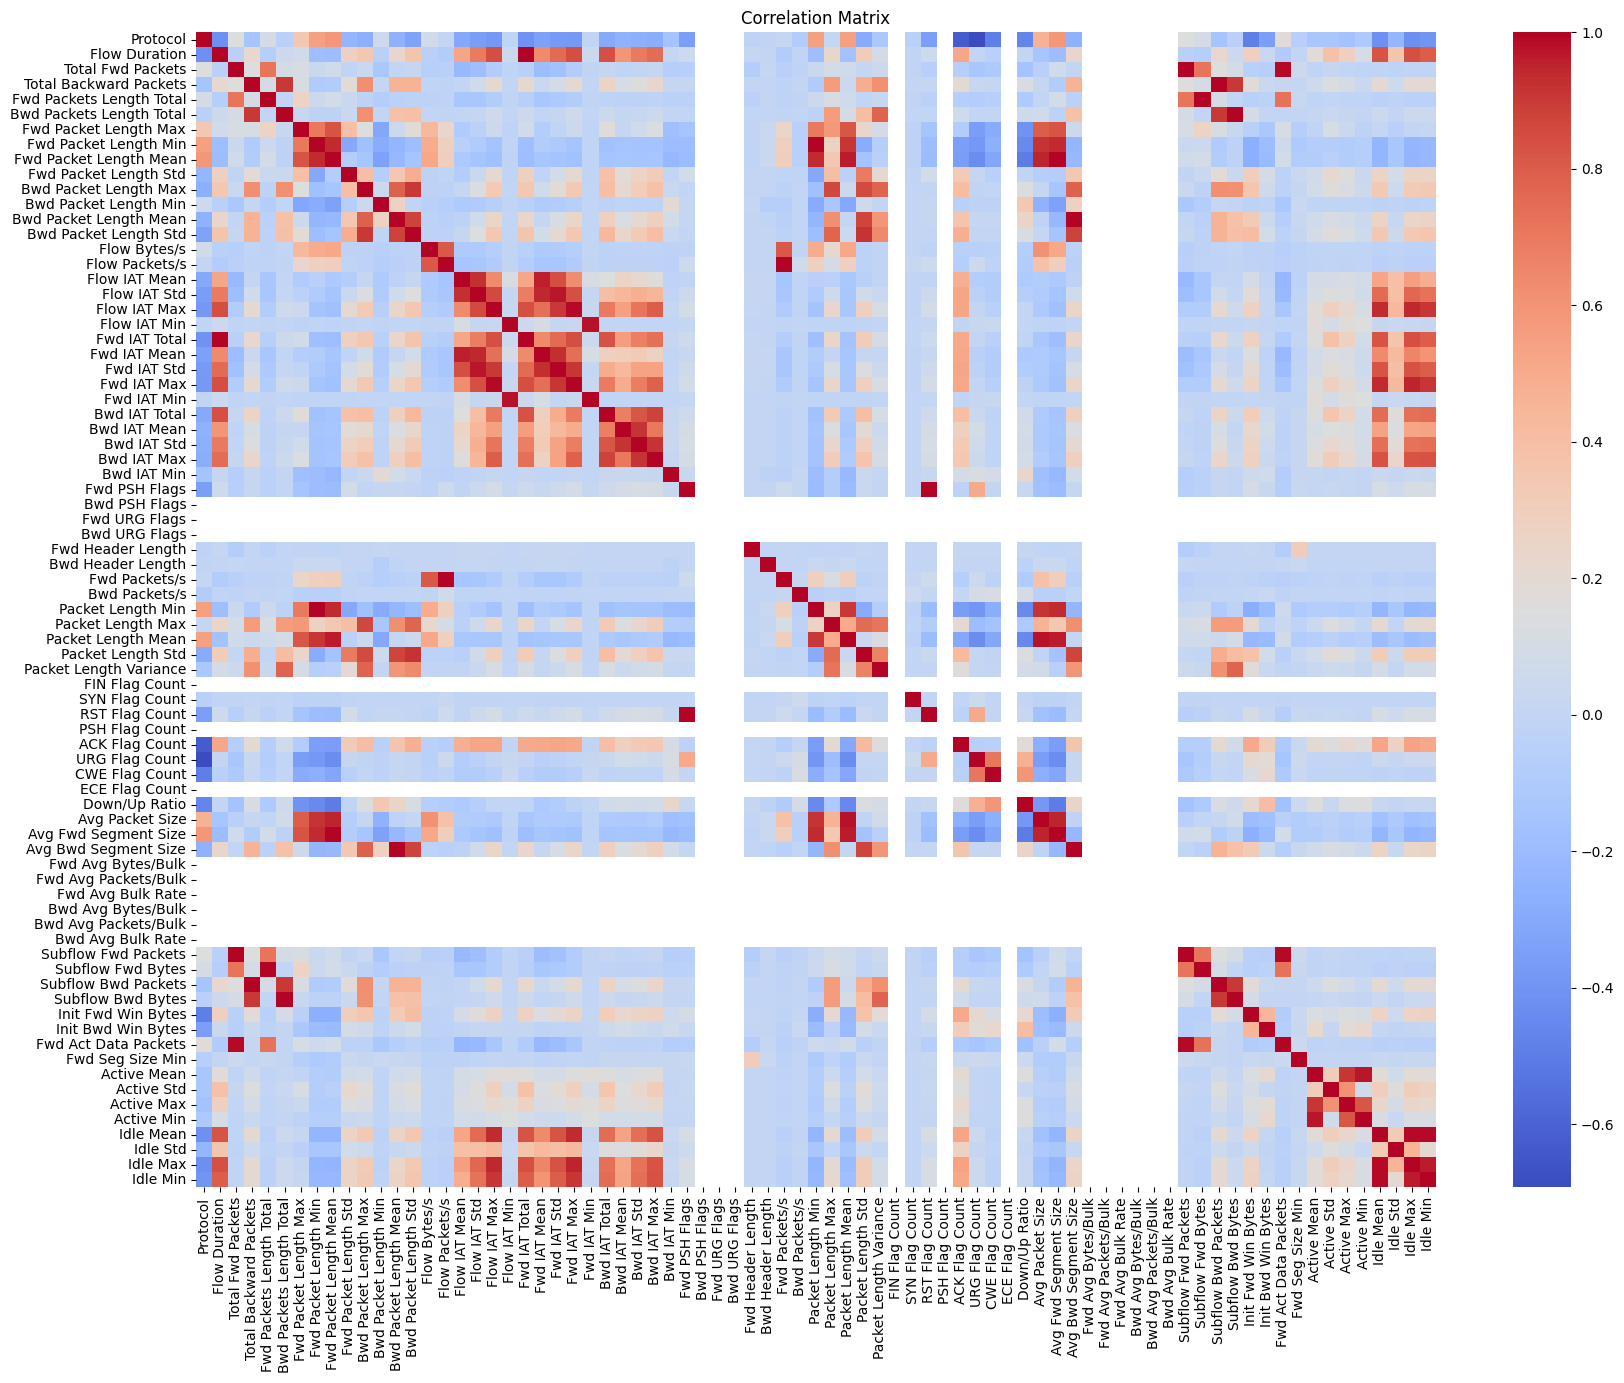

In [22]:
corr_matrix = df1.corr(numeric_only=True)

plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [23]:
corr_matrix = df1.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Features to drop:", to_drop)

Features to drop: ['Bwd Packets Length Total', 'Fwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Mean', 'Packet Length Std', 'RST Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Fwd Act Data Packets', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']


In [24]:
df1_reduced = df1.drop(columns=to_drop)

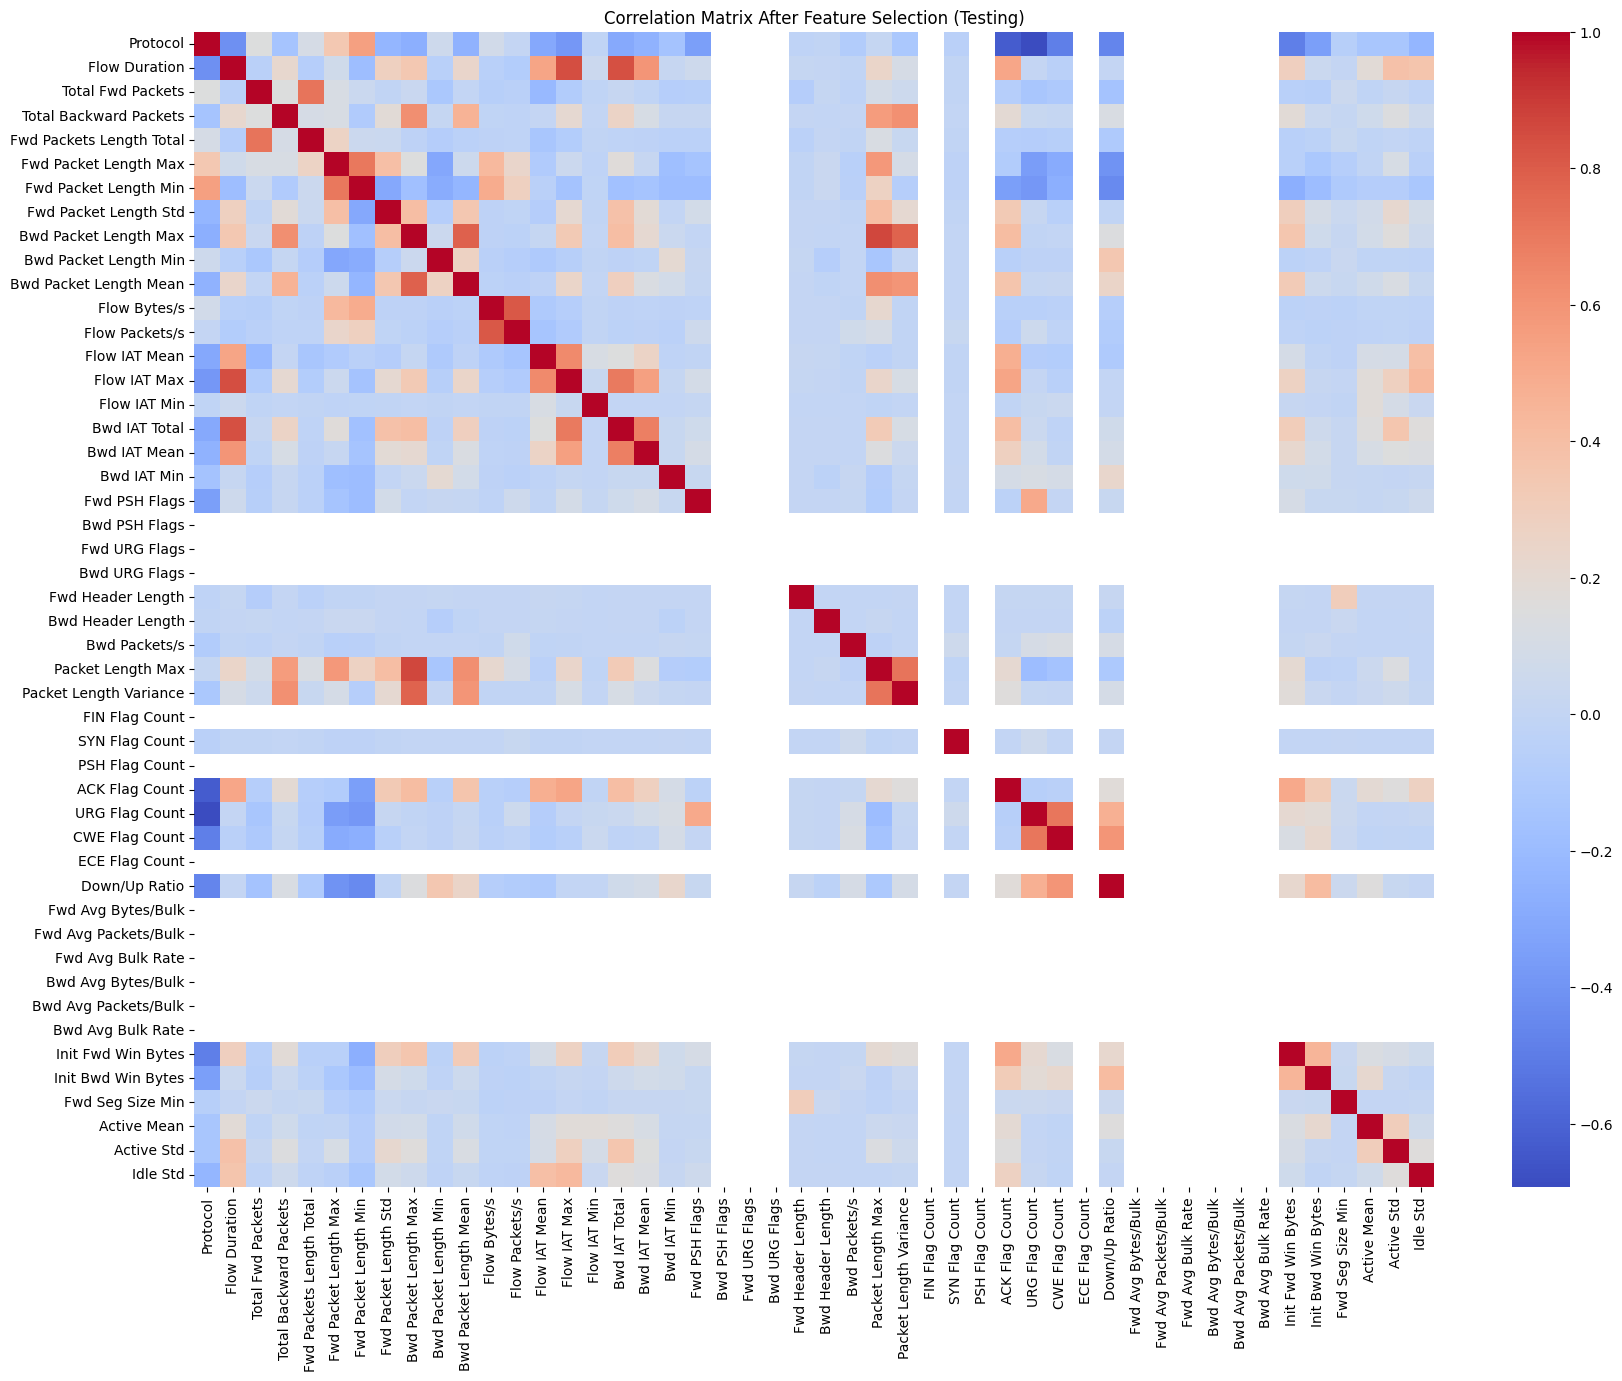

In [25]:
corr_matrix = df1_reduced.corr(numeric_only=True)

plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix After Feature Selection (Testing)")
plt.show()

##### Training Correlation

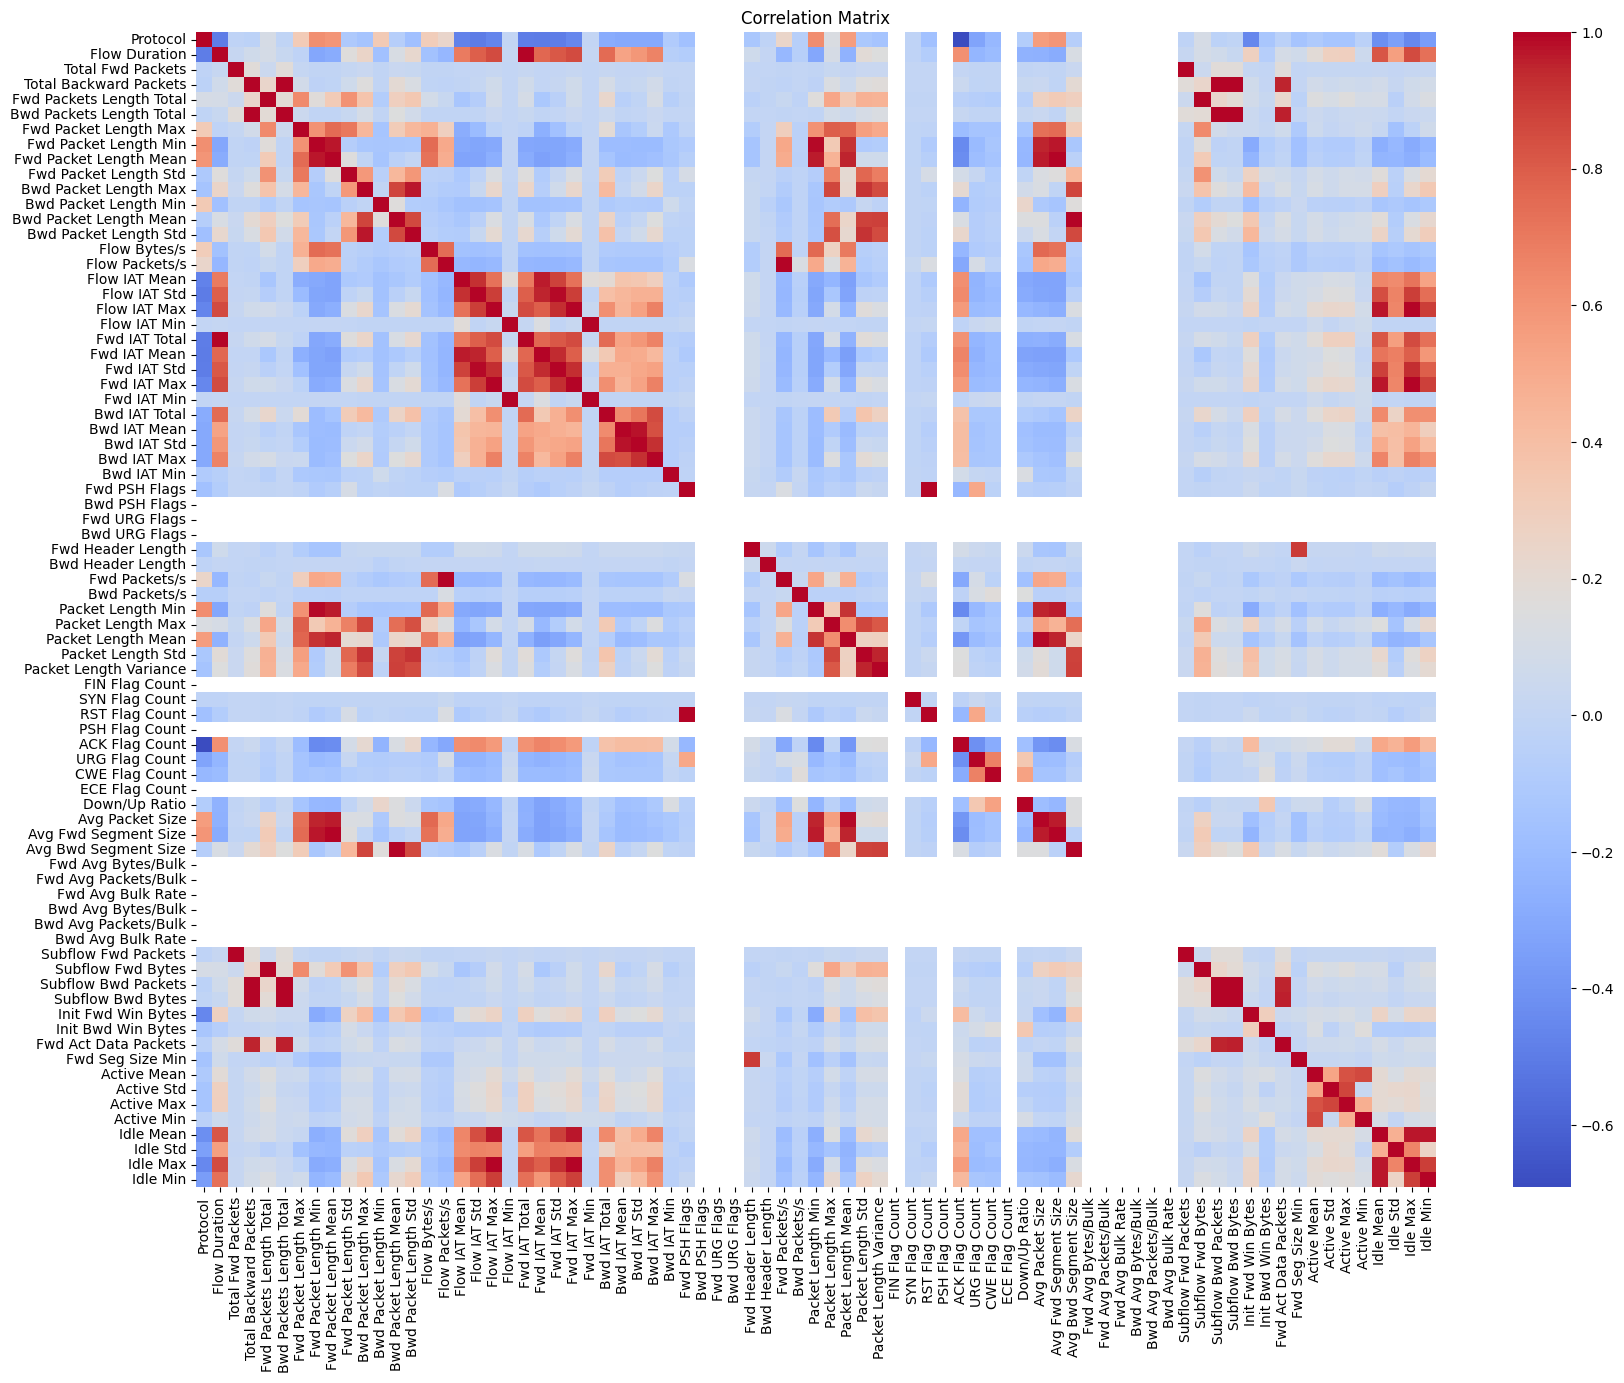

In [26]:
corr_matrix = df2.corr(numeric_only=True)

plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [27]:
corr_matrix = df2.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Features to drop:", to_drop)

Features to drop: ['Bwd Packets Length Total', 'Fwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'RST Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Fwd Act Data Packets', 'Idle Mean', 'Idle Max', 'Idle Min']


In [28]:
df2_reduced = df2.drop(columns=to_drop)

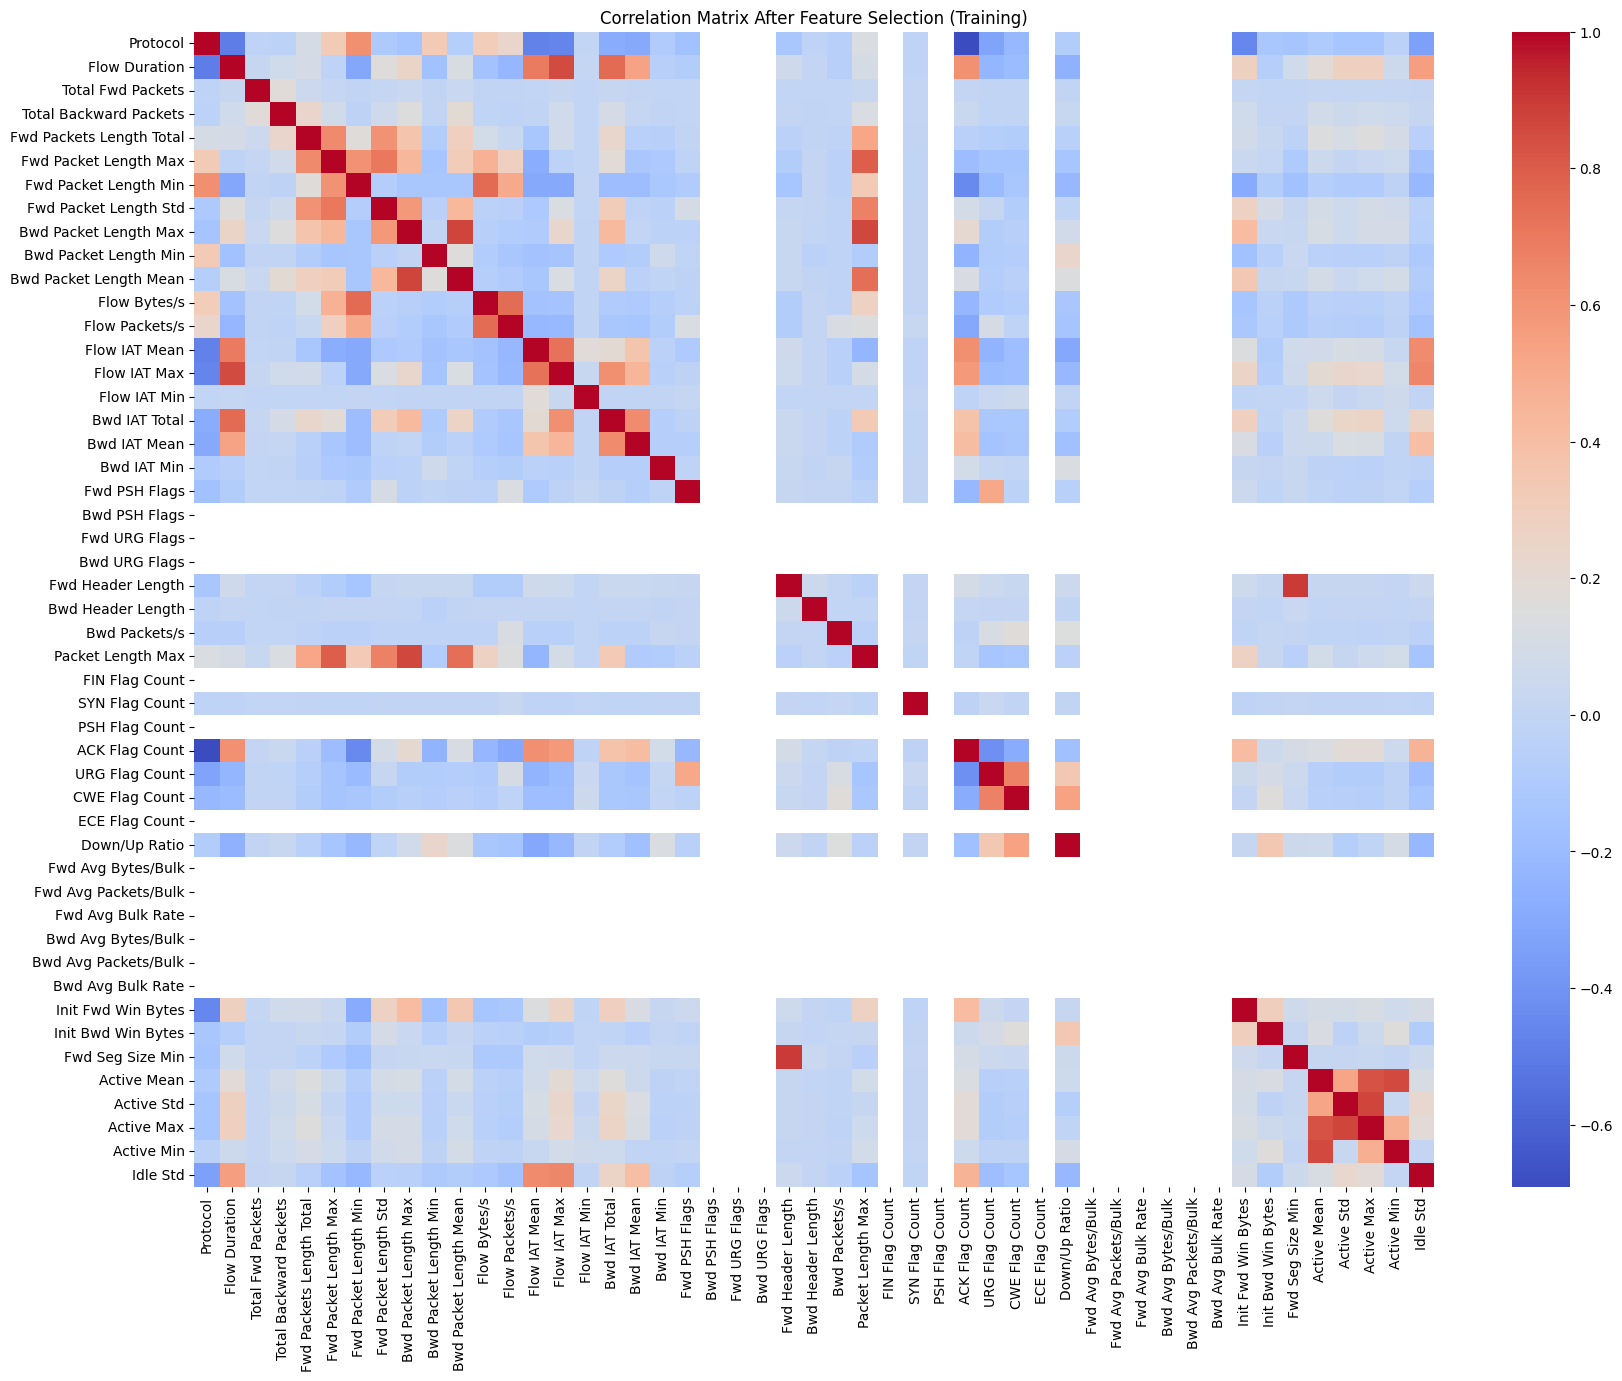

In [29]:
corr_matrix = df2_reduced.corr(numeric_only=True)

plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix After Feature Selection (Training)")
plt.show()